<center><u><H1>Linear Regression</H1></u></center>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
#from sklearn.datasets import load_boston
from sklearn.metrics import r2_score
%matplotlib inline

## Loading data

In [19]:
#boston = load_boston()
#print(boston.DESCR)

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [9]:
data

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]], shape=(506, 13))

In [10]:
target

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

In [11]:
X = data
y = target

In [31]:

columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

df = pd.DataFrame(data, columns=columns)

In [32]:
df['Price'] = target

In [33]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [24]:
cols = ['Price', 'LSTAT', 'INDUS', 'RM', 'AGE']

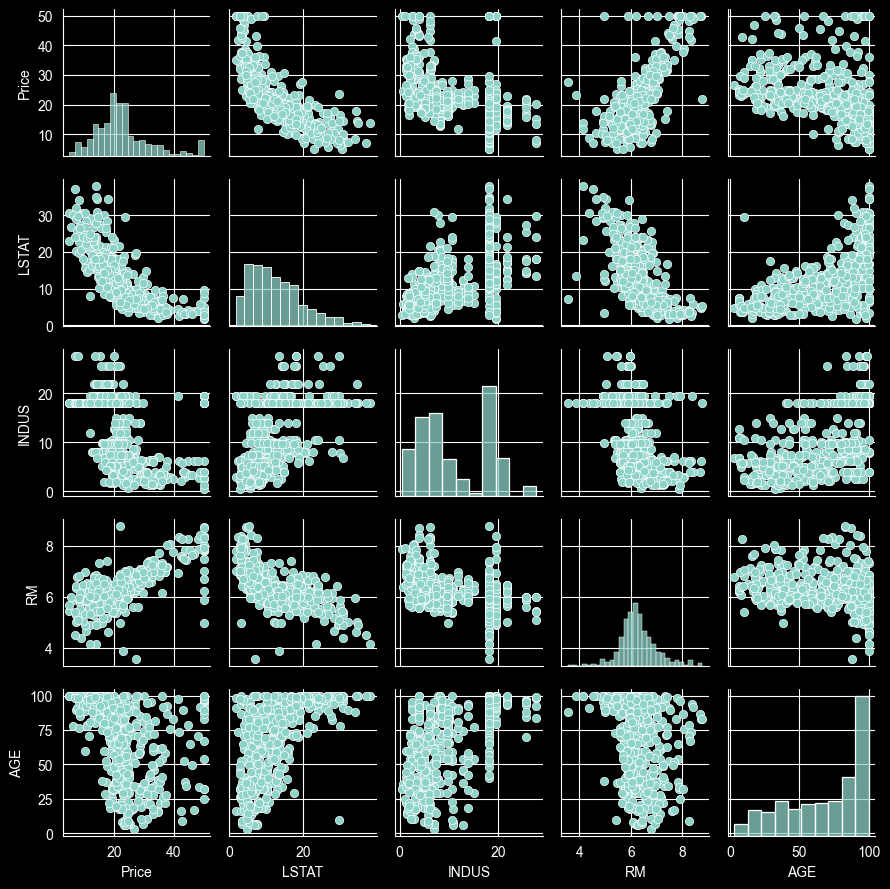

In [35]:
sns.pairplot(df[cols], height=1.8)
plt.tight_layout()

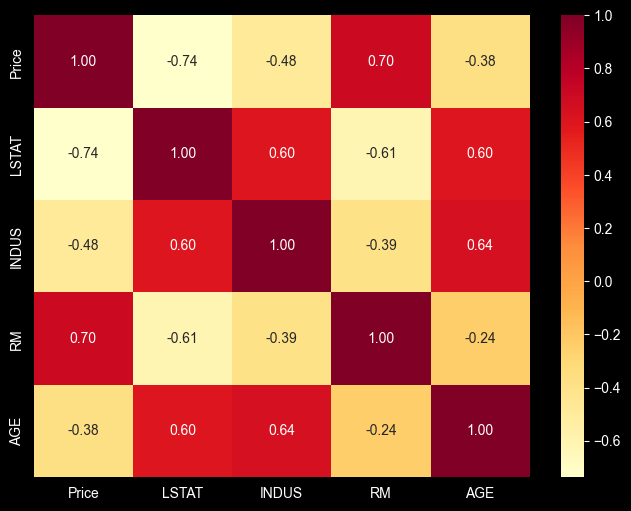

In [36]:
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap="YlOrRd", yticklabels=cols, xticklabels=cols)

## Creating a Linear regression model

In [37]:
lr = LinearRegression()

In [38]:
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
pred = lr.predict(X)

Text(0.5, 1.0, 'Histogram for Predicted prices')

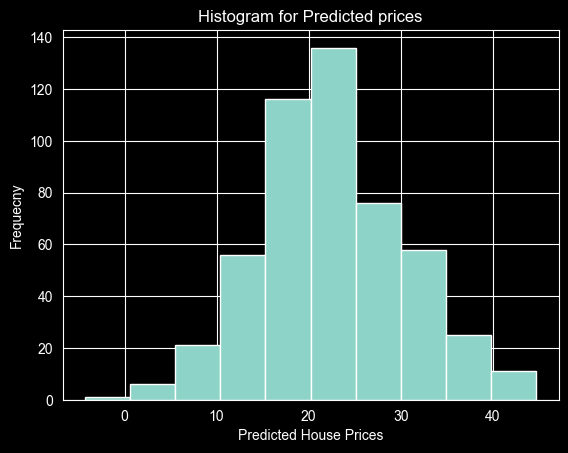

In [40]:
# Histogram: Plot a histogram of all the predicted prices
plt.hist(pred)
plt.xlabel('Predicted House Prices')
plt.ylabel('Frequecny')
plt.title('Histogram for Predicted prices')

## Homoscedasticity and Normality:
### The error variance should be constant, which is known as homocesdasticity and the error should be normally distributed.

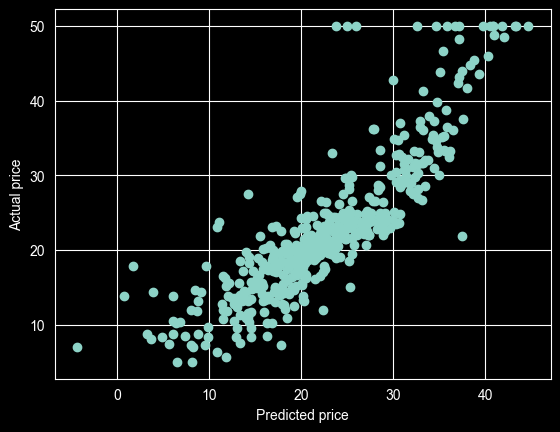

In [41]:
plt.scatter(pred, y)
plt.xlabel('Predicted price')
plt.ylabel('Actual price')
plt.show()

## Plotting residuals

<Axes: >

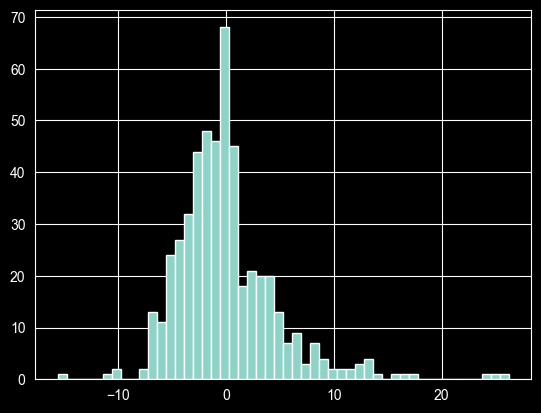

In [42]:
pd.Series(y-pred).hist(bins=50)

## Features and coefficients:

In [45]:
print(list(zip(columns, lr.coef_)))

[('CRIM', np.float64(-0.10801135783679726)), ('ZN', np.float64(0.04642045836688162)), ('INDUS', np.float64(0.020558626367072175)), ('CHAS', np.float64(2.686733819344969)), ('NOX', np.float64(-17.766611228300405)), ('RM', np.float64(3.80986520680924)), ('AGE', np.float64(0.0006922246403435212)), ('DIS', np.float64(-1.4755668456002555)), ('RAD', np.float64(0.3060494789851744)), ('TAX', np.float64(-0.01233459391657437)), ('PTRATIO', np.float64(-0.9527472317072883)), ('B', np.float64(0.009311683273793822)), ('LSTAT', np.float64(-0.5247583778554833))]


In [46]:
lr.intercept_

np.float64(36.45948838508985)

In [49]:
r2 = r2_score(y, pred)
print("R2 on test data: {:.2}".format(r2))

R2 on test data: 0.74


## Cross Validation:

In [50]:
from sklearn.model_selection import cross_val_predict

In [51]:
pred_cv = cross_val_predict(lr, X, y, cv=10)

<Axes: >

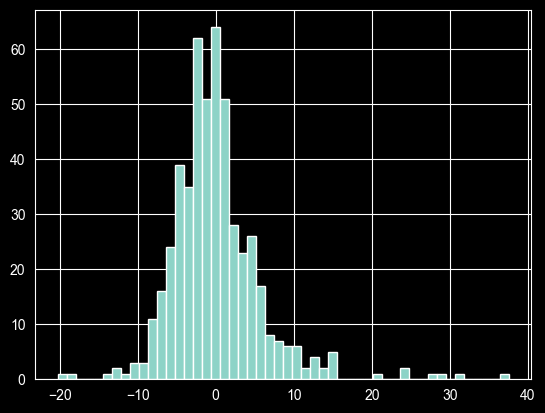

In [52]:
pd.Series(y-pred_cv).hist(bins=50)

## Q-Q plot to test if data is normally distributed

In [53]:
from scipy.stats import probplot
#We will plot our data against a normal distribution to test if our data is distributed normally.

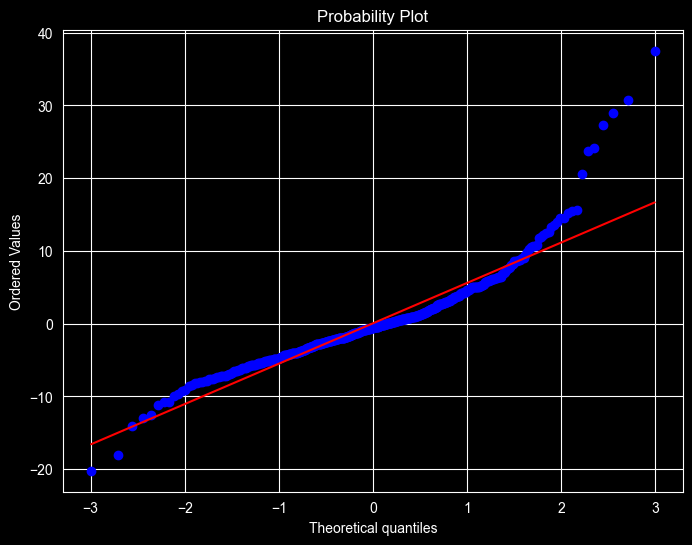

In [54]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
qq = probplot(y - pred_cv, plot=ax)

## MAE and MSE:

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [56]:
print("Mean absolute error(MAE):", mean_absolute_error(y, pred_cv))

Mean absolute error(MAE): 3.997305852593247


In [57]:
print("Mean squared error(MSE):", mean_squared_error(y, pred_cv))

Mean squared error(MSE): 34.539659539993266


## Number of rooms vs House prices:

In [58]:
X_ = df['RM'].values
y_ = df['Price'].values

In [59]:
X_ = X_[:, np.newaxis]
y_ = y_[:, np.newaxis]

In [60]:
X_.shape

(506, 1)

In [61]:
sc_X = StandardScaler()
sc_y = StandardScaler()

In [62]:
X_std = sc_X.fit_transform(X_)
y_std = sc_y.fit_transform(y_)

In [63]:
lr2 = LinearRegression()

In [64]:
lr2.fit(X_std, y_std)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
pred2 = lr2.predict(X_std)

## Plotting Linear Regression Model:

Text(0, 0.5, 'Actual House Prices in $1000s-stardardized')

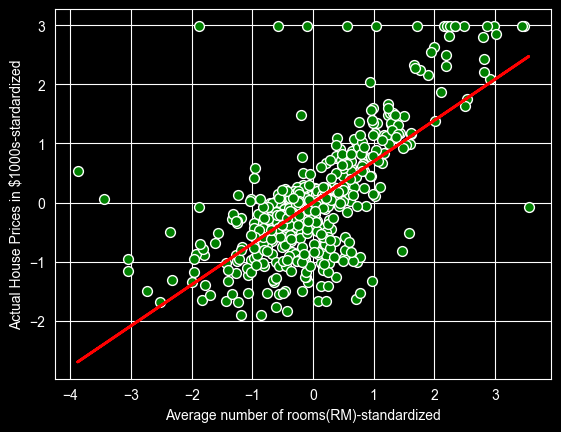

In [66]:
plt.scatter(X_std, y_std, c='green', edgecolor='white', s=50)
plt.plot(X_std, pred2, color='red', lw=2)
plt.xlabel('Average number of rooms(RM)-standardized')
plt.ylabel('Actual House Prices in $1000s-stardardized')

In [86]:
print("Slope: %.3f" % lr2.coef_[0][0])

Slope: 0.695


In [88]:
print("Intercept: %.3f" % lr2.intercept_[0])

Intercept: -0.000


## Making predictions:

In [77]:
n_rooms = 8

In [82]:

# User input
n_rooms = 8

# Scale input
n_rooms_std = sc_X.transform([[n_rooms]])


In [83]:
price_std = lr2.predict(n_rooms_std)
price_std

array([[1.69932794]])

In [85]:
print("Price in $1000s: %.3f" % sc_y.inverse_transform(price_std)[0][0])

Price in $1000s: 38.146


## Reference:

http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html